In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import struct, os

from utils.pluto import PlutoData
from utils.visualize import DefaultStyle
from utils.visualize import set_style, get_cbar
set_style()

In [3]:
# Path = '/media/yange/MyDrive/2024PhDData/pluto-runs/local/IA2/E14_10to11/test9'
# Path = "/home/yange/Documents/2024PhD/Project/plutotests/IA2/test9-staticpot/"
# Path = "/home/yange/Documents/2024PhD/Project/plutotests/IA2/test17-squarepot/"
Path = "/home/yange/Documents/2024PhD/Project/plutotests/IA2/"
# Path = "/home/yange/Documents/2024PhD/PLUTO-4.4v3/Test_Problems/InterpolateBodyForcePotential/test6-interpolatetimes/"
# Path = "/home/yange/Documents/2024PhD/PLUTO-4.4v3/Test_Problems/InterpolateBodyForcePotential"
pd = PlutoData(Path)

In [4]:
varNames = ['rho','prs','pot','vx1','vx2','vx3','Bx1','Bx2','Bx3']
# varNames = ['rho','prs','vx1','vx2','vx3','Bx1','Bx2','Bx3']

In [5]:
pd.varNames

['Bx1', 'Bx2', 'Bx3', 'pot', 'prs', 'rho', 'vx1', 'vx2', 'vx3']

DefaultStyle catalogue does not include pot. Returning to default.


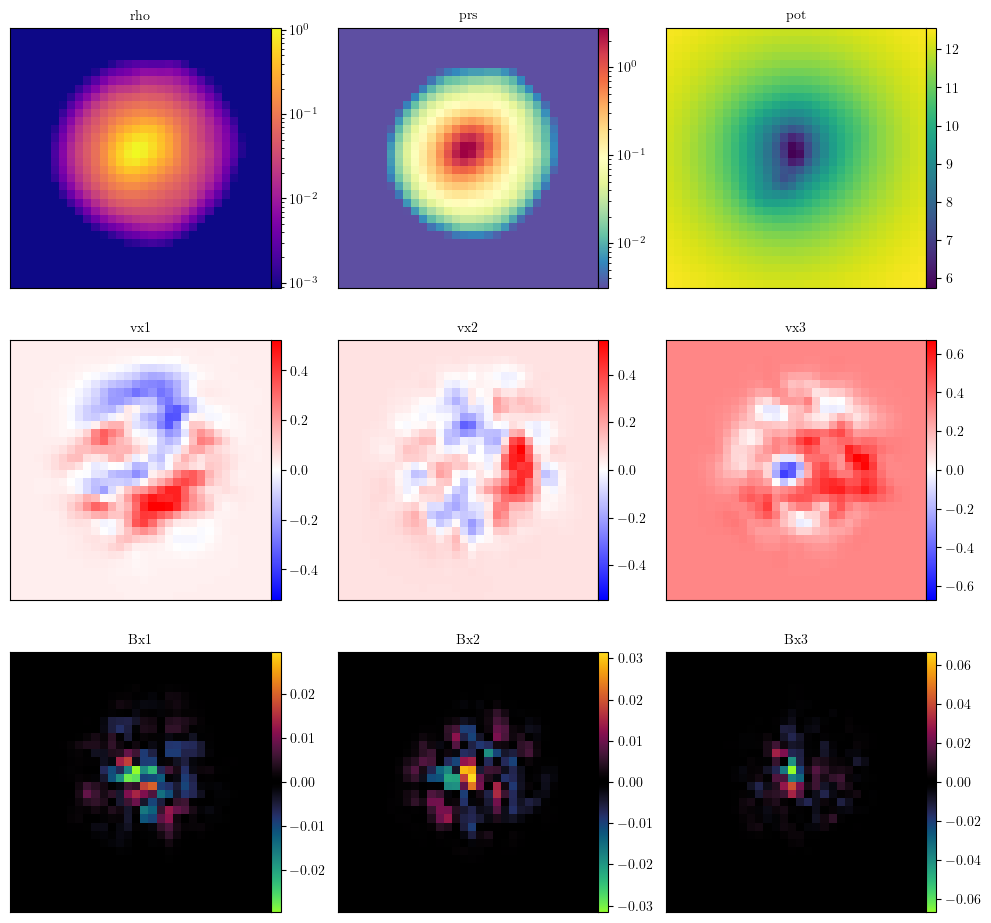

DefaultStyle catalogue does not include pot. Returning to default.


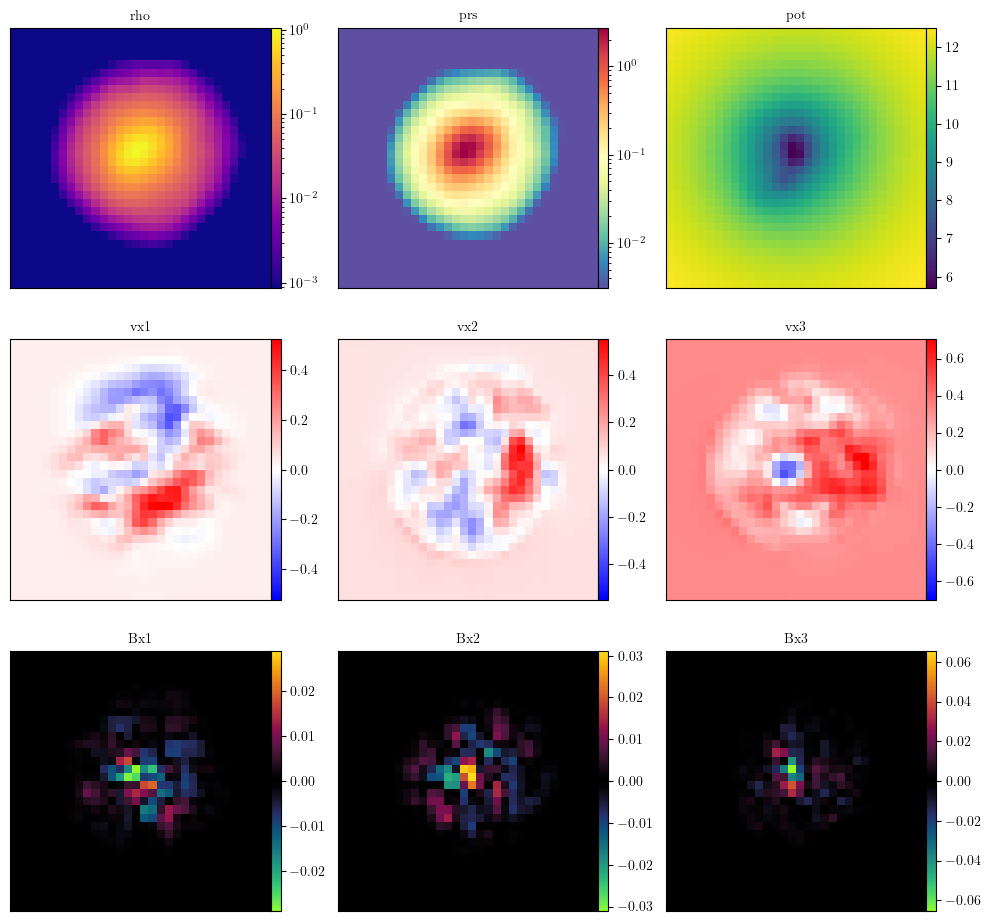

DefaultStyle catalogue does not include pot. Returning to default.


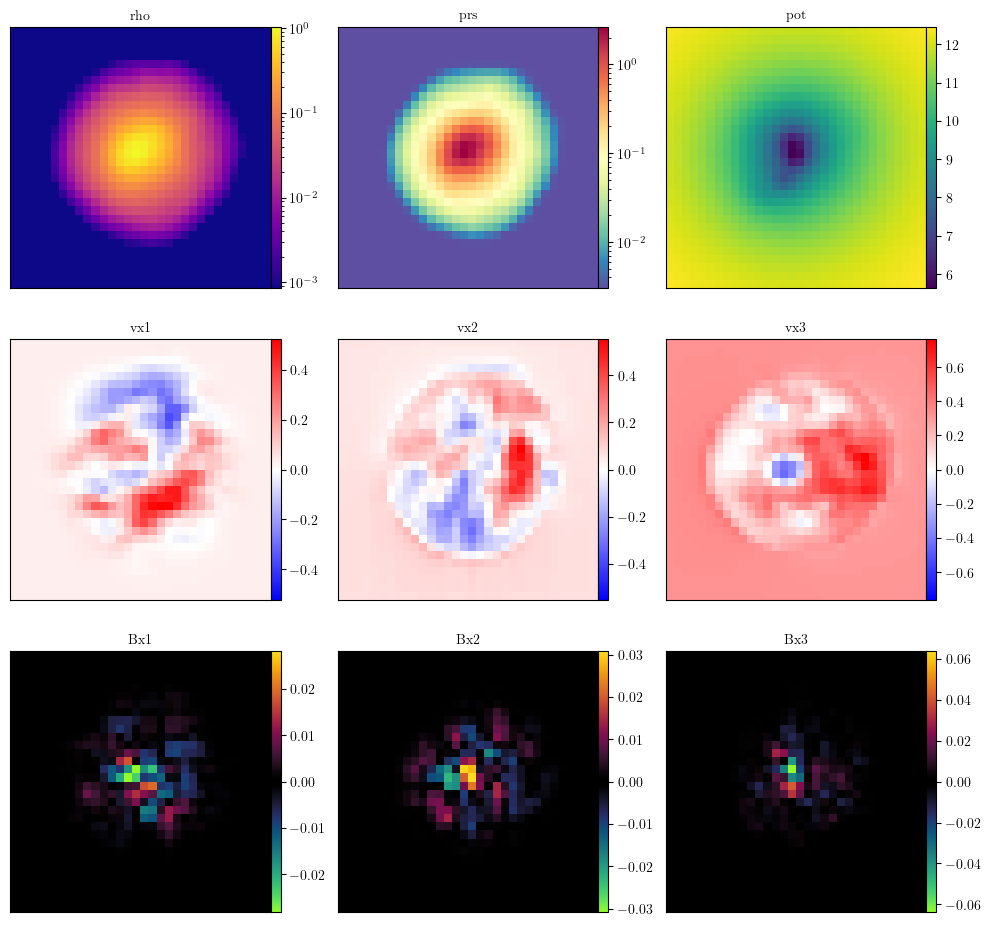

DefaultStyle catalogue does not include pot. Returning to default.


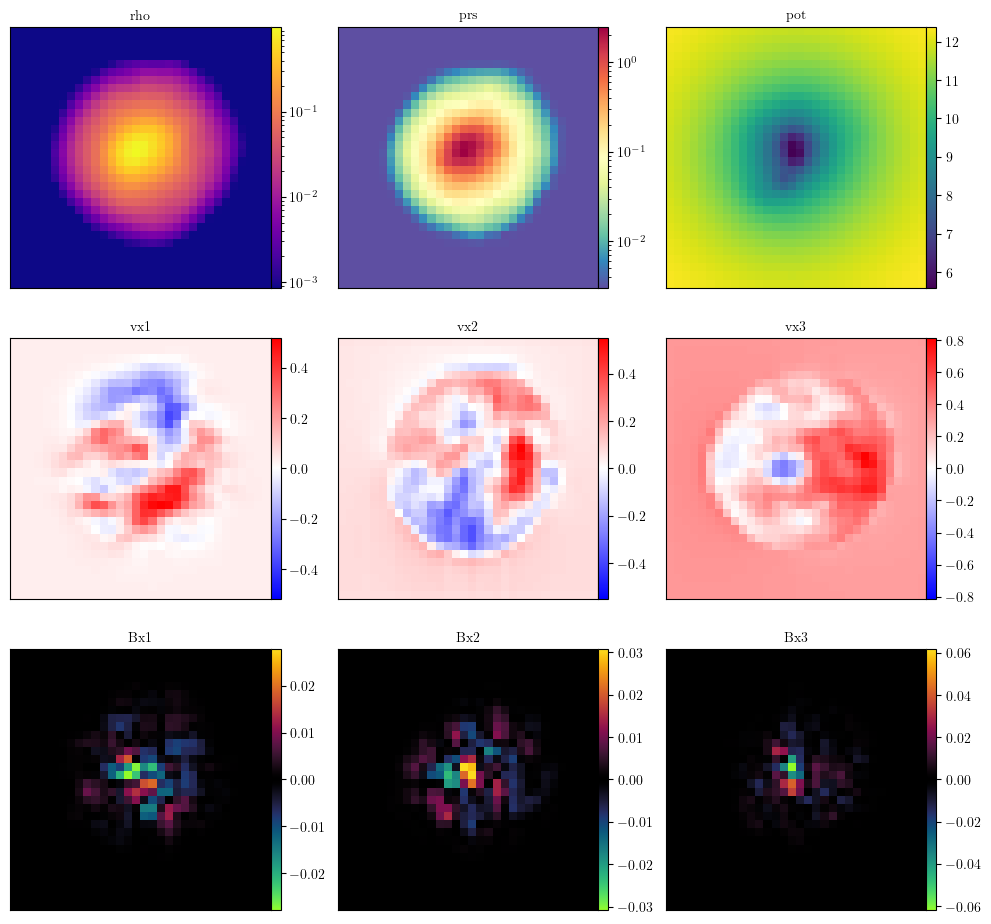

DefaultStyle catalogue does not include pot. Returning to default.


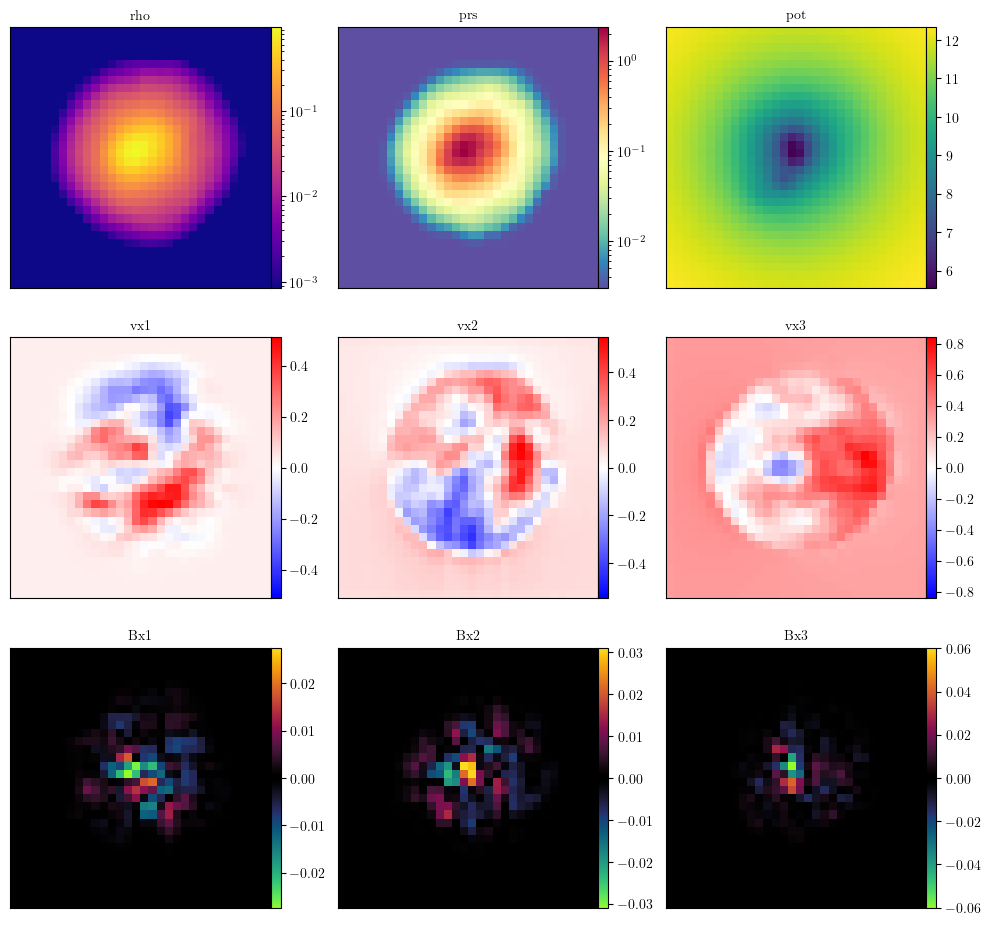

DefaultStyle catalogue does not include pot. Returning to default.


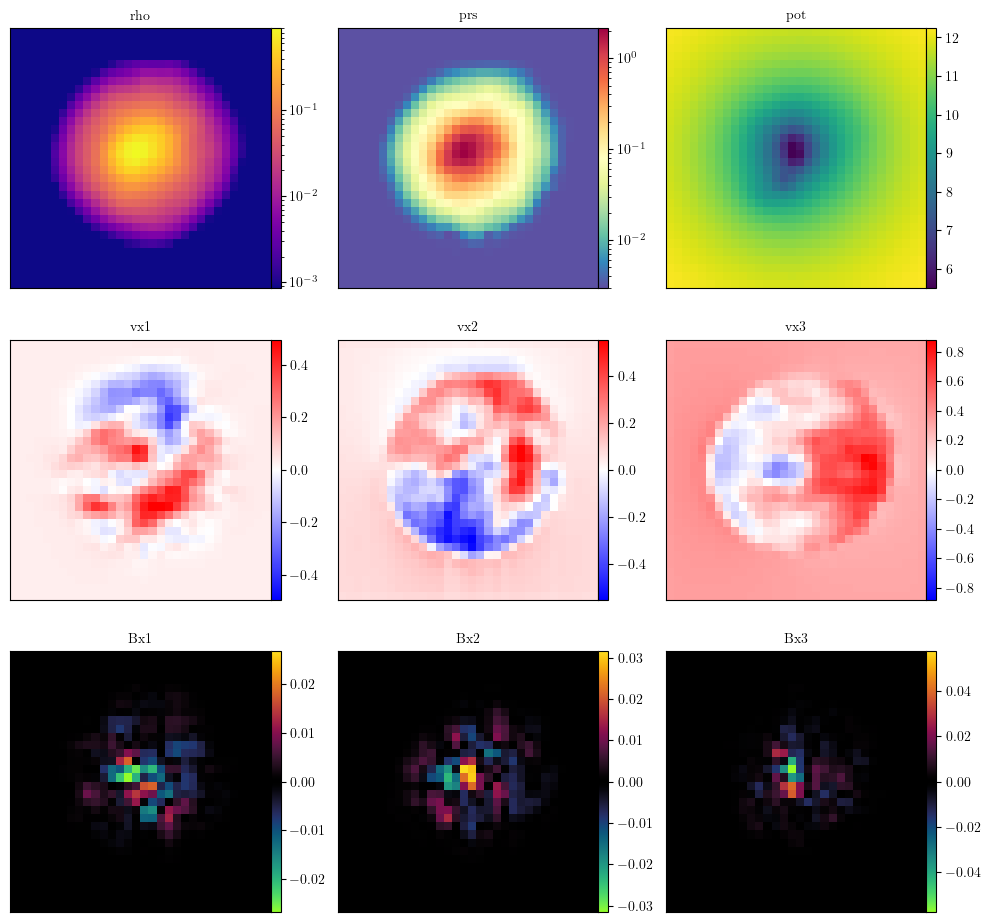

DefaultStyle catalogue does not include pot. Returning to default.


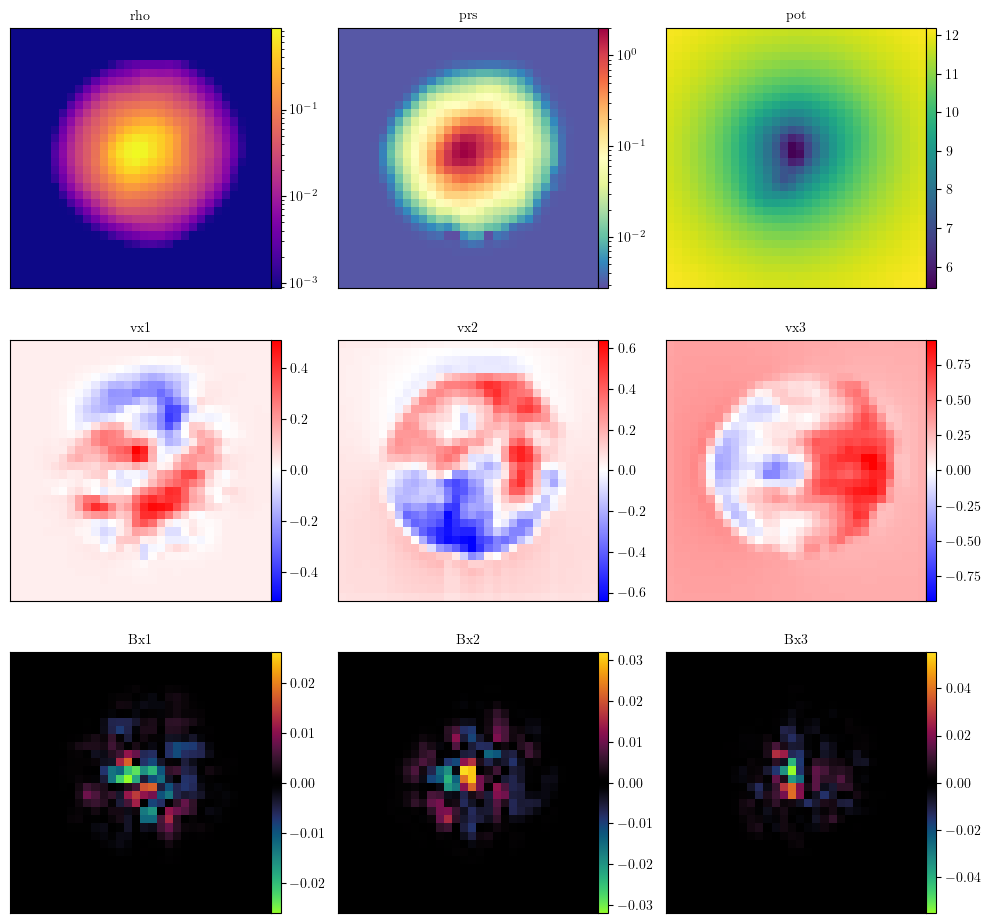

DefaultStyle catalogue does not include pot. Returning to default.


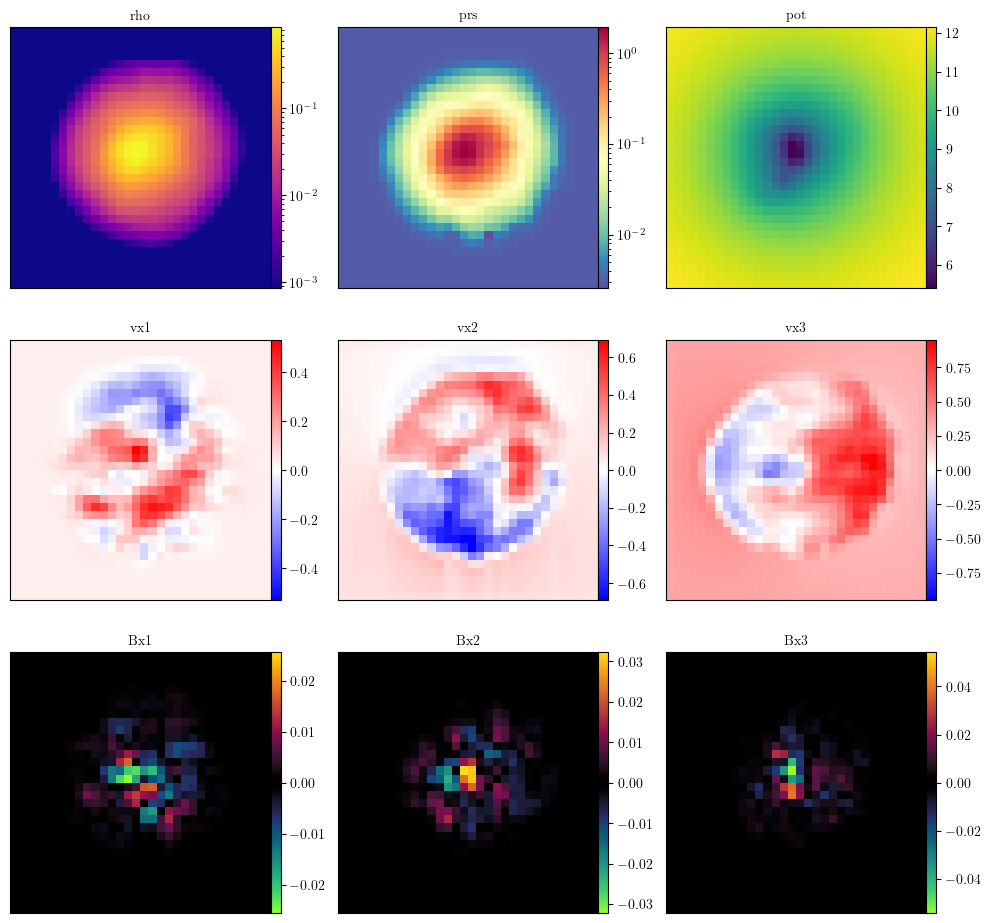

DefaultStyle catalogue does not include pot. Returning to default.


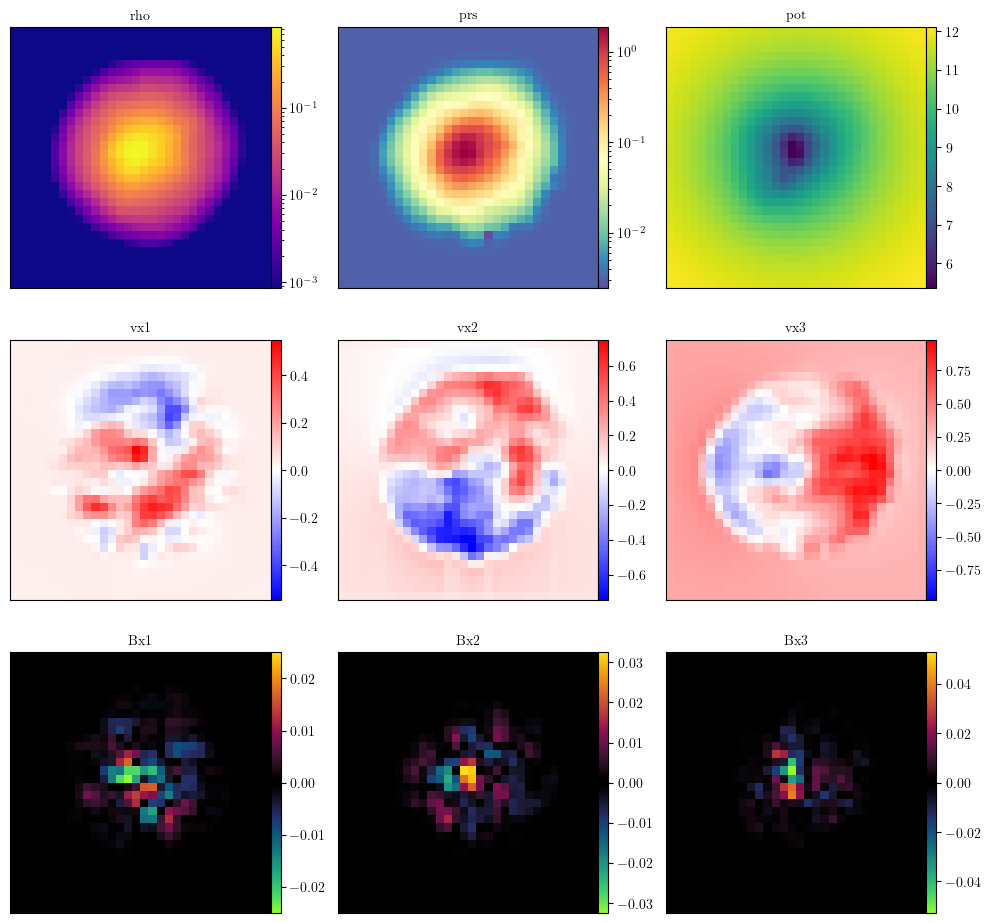

DefaultStyle catalogue does not include pot. Returning to default.


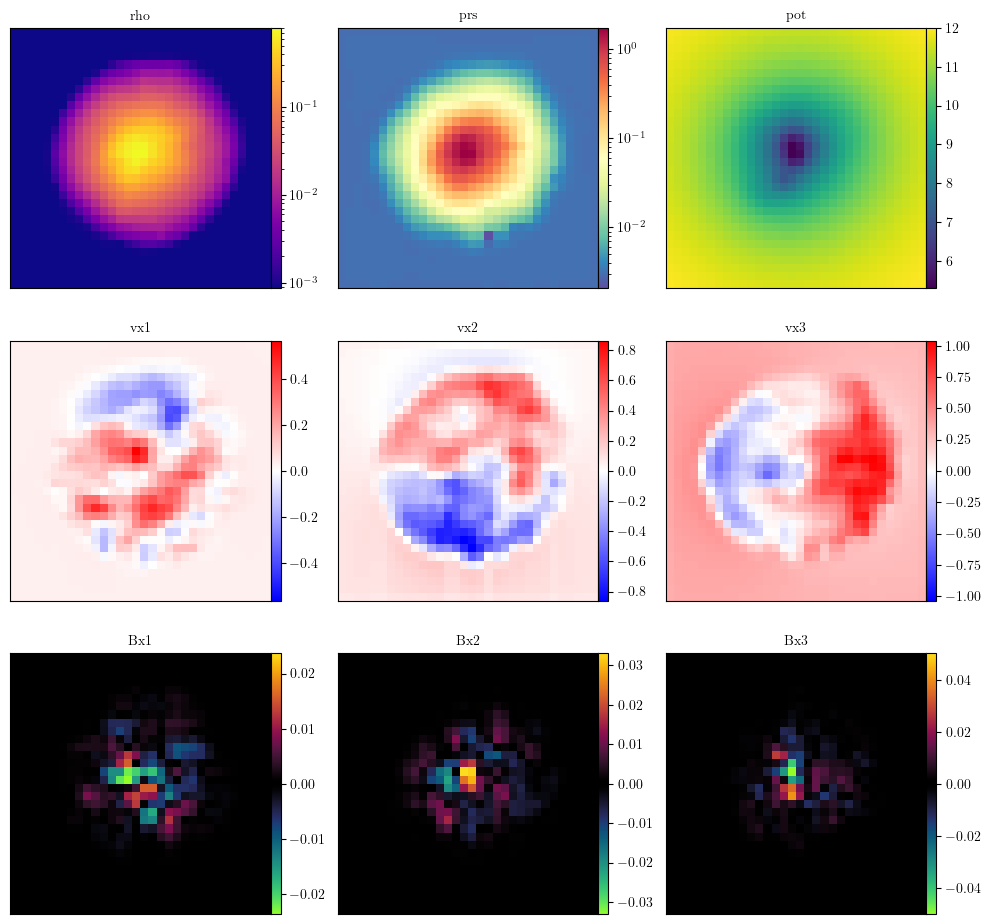

DefaultStyle catalogue does not include pot. Returning to default.


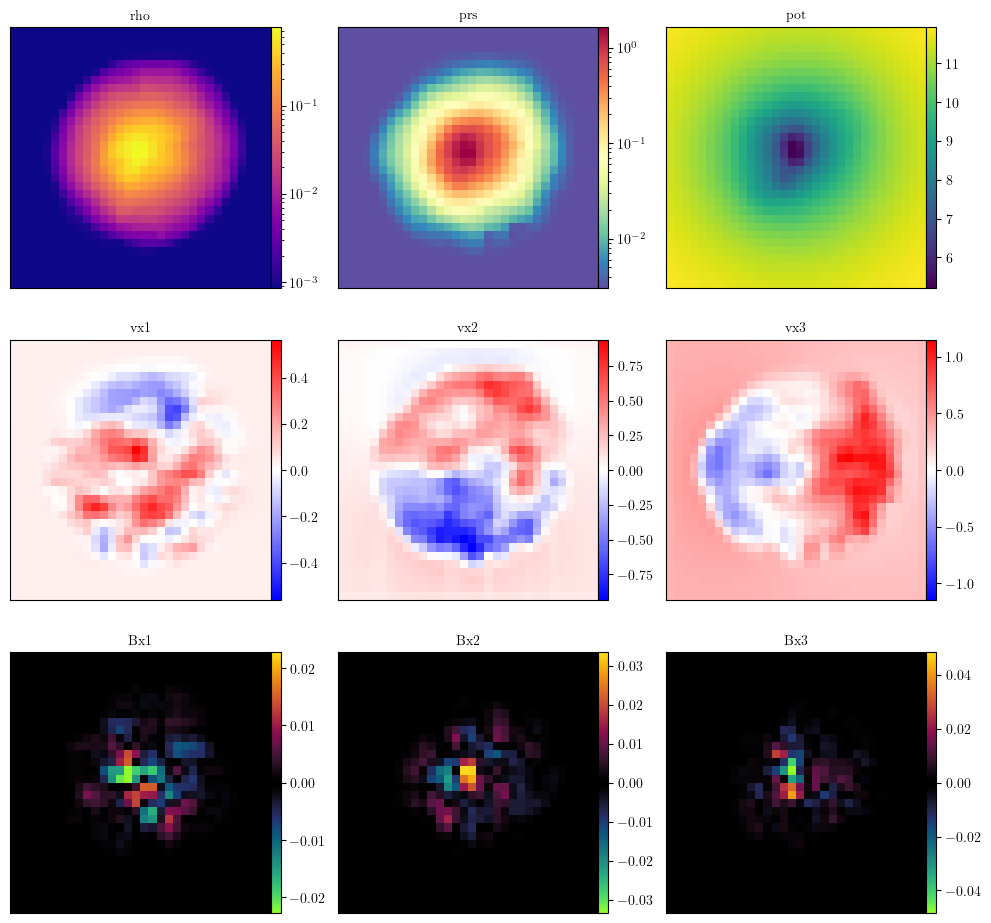

In [6]:
for snapshot in range(len(pd.times)):
    
    vals_raw = {}
    for varName in varNames:
        vals_raw.update({varName : pd.get_vals(varName, snapshots=snapshot, units='code')[0]})
    
    fig = plt.figure(figsize=(10,9.5),tight_layout=True)
    for i, (key, val) in enumerate(vals_raw.items()):
        ax = fig.add_subplot(3,3,i+1)
        ax.set_xticks([])
        ax.set_yticks([])
        val = val[pd.shape[0]//2]
        # val = val[0]
        
        norm = None
        if key in {'rho','dm','prs'}:
            norm = LogNorm()
            # norm = None
        if key.startswith('vx') or key.startswith('Bx'):
            vmax = np.abs(val).max()
            vmin = -vmax
        else:
            vmin, vmax = None, None
        cmap = DefaultStyle.get_varkwargs(key)['cbar_cmap']
        ax.set_aspect(1)
        ax.set_title(key)
        im = ax.pcolormesh(val,cmap=cmap,vmin=vmin,vmax=vmax,norm=norm)
        cbar = get_cbar(im,fig,ax,cbar_pad=0,cbar_size=.1)
    plt.show()

# Consider Potentials

In [7]:
pot_1 = []
for s in range(len(pd.times)):
    pot_1.append(pd.get_vals("pot", snapshots=s, units='code')[0])

In [8]:
for pot in pot_1:
    assert (pot==pot_1[0]).all()

AssertionError: 

In [8]:
Path2 = "/home/yange/Documents/2024PhD/PLUTO-4.4v3/Test_Problems/InterpolateBodyForcePotential/test3-shiftxidx/"
pd2 = PlutoData(Path2)

TODO: pluto.py self.FORCED_TURB -- make this optional.


In [9]:
pot_2 = []
for s in range(len(pd2.times)):
    pot_2.append(pd2.get_vals("pot", snapshots=s, units='code')[0])

In [10]:
for pot in pot_2:
    assert (pot==pot_2[0]).all()

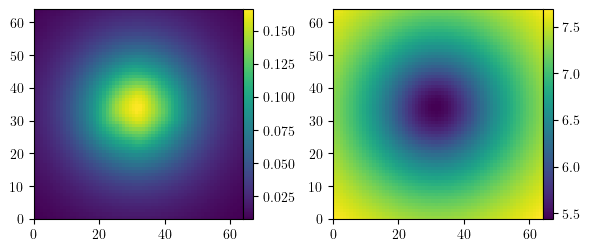

In [17]:
fig, axes = plt.subplots(1,2,figsize=(6,4,),tight_layout=True)

for ax in axes:
    ax.set_aspect("equal")
    
im = axes[0].pcolormesh(pot_1[0][16]-pot_2[0][17])
cbar = get_cbar(im, fig, axes[0])

im = axes[1].pcolormesh(pot_2[0][17])
cbar = get_cbar(im, fig, axes[1])

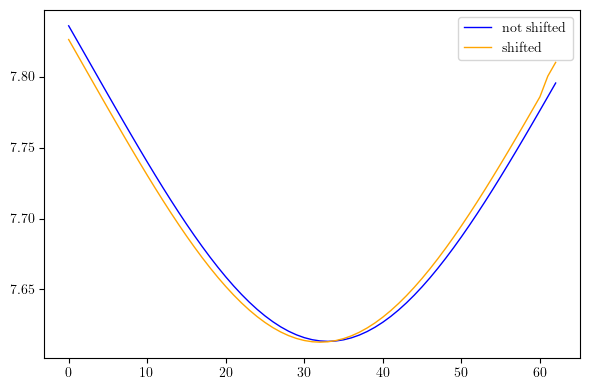

In [19]:
fig, ax = plt.subplots(1,1,figsize=(6,4,),tight_layout=True)
    
ax.plot(pot_1[0][:,0,0][:-1],label='not shifted')

ax.plot(pot_2[0][:,0,0][1:], label='shifted')

ax.legend()

# Load OG potential

In [9]:
import struct
n_points = np.prod(pd.shape)

with open(os.path.join(Path, 'pot00.dbl'),'rb') as f:
    pot_og = struct.unpack('<'+'d'*n_points,f.read())
pot_og = np.array(pot_og).reshape(pd.shape)

In [10]:
pot_out = pd.get_vals('pot', snapshots=0, units='code')[0]

In [11]:
pot_out.shape, pot_og.shape

((64, 64, 64), (64, 64, 64))

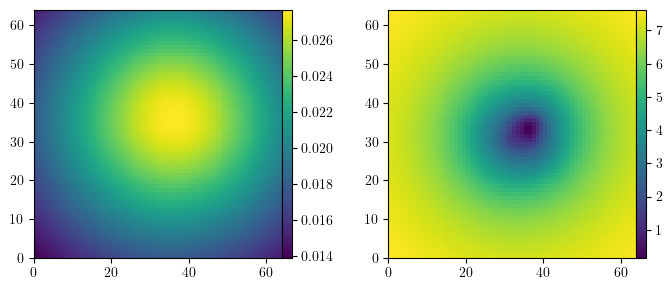

In [12]:
fig, axes = plt.subplots(1,2,figsize=(7,3),tight_layout=True)

for ax in axes:
    ax.set_aspect(1)

im = axes[0].pcolormesh((pot_og-pot_out.T)[-1])
cbar = get_cbar(im,fig,axes[0])
im = axes[1].pcolormesh(pot_out.T[:,32])
cbar = get_cbar(im,fig,axes[1])

plt.show()

In [52]:
np.isclose(pot_og,pot_out.t).all()

np.False_

In [46]:
pot_og[2:62,2:62,2:62]==pot_out[:60,:60,:60]

array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, Fal

# Load OG density

In [65]:
import struct
n_points = np.prod(pd.shape)

with open(os.path.join(Path, 'rho0.dbl'),'rb') as f:
    rho_og = struct.unpack('<'+'d'*n_points,f.read())
rho_og = np.array(rho_og).reshape(pd.shape)

In [66]:
rho_out = pd.get_vals('rho', snapshots=0, units='code')[0]

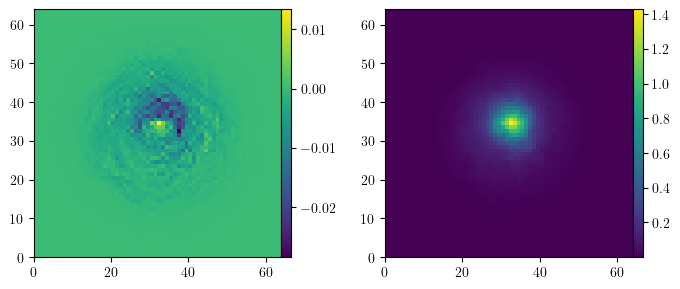

In [68]:
fig, axes = plt.subplots(1,2,figsize=(7,3),tight_layout=True)

for ax in axes:
    ax.set_aspect(1)

im = axes[0].pcolormesh(rho_og[32]-rho_out.T[32])
cbar = get_cbar(im,fig,axes[0])
im = axes[1].pcolormesh(rho_out.T[32])
cbar = get_cbar(im,fig,axes[1])

plt.show()

In [74]:
xbeg, xend = -0.9187367817786017, 0.9187367817786017
N = 64

In [75]:
(xend-xbeg)/N

0.028710524430581304

In [78]:
x = np.arange(-N//2,N//2) * (xend-xbeg)/N + (xend-xbeg)/N/2
x

array([-0.90438152, -0.875671  , -0.84696047, -0.81824995, -0.78953942,
       -0.7608289 , -0.73211837, -0.70340785, -0.67469732, -0.6459868 ,
       -0.61727628, -0.58856575, -0.55985523, -0.5311447 , -0.50243418,
       -0.47372365, -0.44501313, -0.4163026 , -0.38759208, -0.35888156,
       -0.33017103, -0.30146051, -0.27274998, -0.24403946, -0.21532893,
       -0.18661841, -0.15790788, -0.12919736, -0.10048684, -0.07177631,
       -0.04306579, -0.01435526,  0.01435526,  0.04306579,  0.07177631,
        0.10048684,  0.12919736,  0.15790788,  0.18661841,  0.21532893,
        0.24403946,  0.27274998,  0.30146051,  0.33017103,  0.35888156,
        0.38759208,  0.4163026 ,  0.44501313,  0.47372365,  0.50243418,
        0.5311447 ,  0.55985523,  0.58856575,  0.61727628,  0.6459868 ,
        0.67469732,  0.70340785,  0.73211837,  0.7608289 ,  0.78953942,
        0.81824995,  0.84696047,  0.875671  ,  0.90438152])

In [ ]:
pot = [-0.008535, -0.013319, -0.013340, -0.018259, -0.008535, 0.000000, -0.013340, -0.018259]
idx = [2.000000, 2.500000, 2.500000]